<a href="https://colab.research.google.com/github/burningdust/ESAA/blob/main/YB_assignment/ESAA_YB_study20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 개념 정리

## 7. 군집화

### 7-1. K-평균 알고리즘 이해

K-평균: 군집화에서 가장 일반적으로 사용되는 알고리즘. 군집 중심점(centroid)을 선택해 해당 중심에 가장 가까운 포인트들을 선택하는 군집화 기법.
- 군집 중심점이 선택된 포인트의 평균 지점으로 이동 후 이동된 중심점에서 가까운 포인트를 선택, 다시 중심점을 평균 지점으로 이동하는 프로세스 반복 수행.
- 알고리즘이 쉽고 간결.
- 거리 기반 알고리즘으로 속성의 개수가 많을 경우 군집화 정확도가 떨어짐. (PCA로 차원 감소 적용 필요)
- 반복 횟수가 많을 경우 수행 시간이 느림.
- 군집 개수 선택이 애매함.

사이킷런 패키지의 KMeans 클래스
- n_clusters : 군집 개수
- init: 초기 군집 중심점 좌표 설정 방식. 일반적으로 k-means++로 설정.
- max_iter: 최대 반복 횟수. 이전에도 중심점 이동이 없으면 종료함.
- labels_로 각 데이터 포인트가 속한 군집 중심점 레이블을, cluster_centers_로 각 군집 중심점 좌표를 불러올 수 있음.

군집화 알고리즘 테스트를 위한 데이터 생성 API : 대표적으로 make_blobs(), make_classification(). 여러 개의 클래스에 해당하는 데이터 세트 생성. make_blobs()는 개별 군집의 중심점과 표준 편차 제어 기능이, make_classificaton()는 노이즈를 포함한 데이터 생성 기능이 있음.

### 7-2. 군집 평가(Cluster Evaluation)

실루엣 분석(silhouette analysis) : 각 군집 간의 거리가 얼마나 효율적으로 분리되어 있는지를 나타내는 군집화 평가 방법. 개별 데이터가 가지는 군집화 지표인 실루엣 계수를 기반으로 함.
- 실루엣 계수 s(i) = (b(i) - a(i)) / (max(a(i), b(i)))
- 실루엣 계수는 -1에서 1 사이의 값이고 1에 가까울수록 근처 군집과 더 멀리 떨어져 있다는 뜻.
- 전체 실루엣 계수의 평균값이 0~1 사이의 값이며 1에 가까울수록 좋고, 개별 군집의 평균값의 편차가 크지 않아야 함.
- 직관적으로 이해하기 쉽지만 데이터가 크면 수행 시간이 오래 걸리고 에러가 발생하기 쉬우므로 군집별로 임의의 데이터를 샘플링하는 방안 필요.

# 코드 필사

## 7. 군집화

### 7-1. K-평균 알고리즘 이해

In [3]:
# class.sklearn.cluster.Kmeans(n_clusters = 8, init = 'k-means++', n_init = 10, max_iter = 300, tol = 0.0001,
#                               precompute_distances = 'auto', verbose = 0, random_state = None,
#                               copy_x = True, n_jobs = 1, algorithm = 'auto')

#### K-평균을 이용한 붓꽃 데이터 세트 군집화

In [2]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
# 더 편리한 데이터 핸들링을 위해 DataFrame으로 변환
irisDF = pd.DataFrame(data = iris.data, columns = ['sepal_length', 'sepal_width',
                                                   'petal_length', 'petal_width'])
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [4]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 300, random_state = 0)
kmeans.fit(irisDF)

KMeans(n_clusters=3, random_state=0)

In [5]:
print(kmeans.labels_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [6]:
irisDF['target'] = iris.target
irisDF['cluster'] = kmeans.labels_
iris_result = irisDF.groupby(['target', 'cluster'])['sepal_length'].count()
print(iris_result)

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64


In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
pca_transformed = pca.fit_transform(iris.data)

irisDF['pca_x'] = pca_transformed[:, 0]
irisDF['pca_y'] = pca_transformed[:, 1]
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,-2.888991,-0.144949


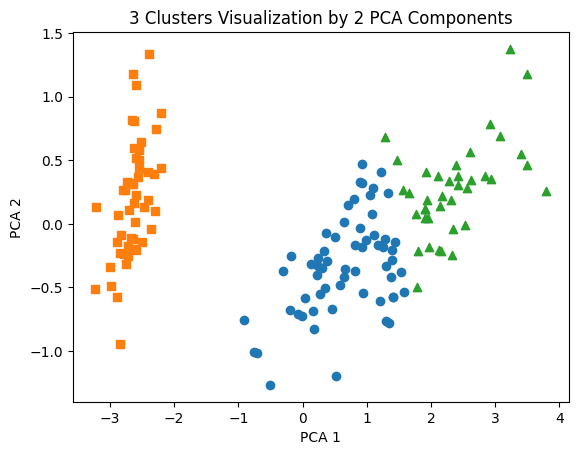

In [8]:
# 군집 값이 0, 1, 2인 경우마다 별도의 인덱스로 추출
marker0_ind = irisDF[irisDF['cluster'] == 0].index
marker1_ind = irisDF[irisDF['cluster'] == 1].index
marker2_ind = irisDF[irisDF['cluster'] == 2].index

# 군집 값 0, 1, 2에 해당하는 인덱스로 각 군집 레벨의 pca_x, pca_y 값 추출. o, s, ^로 마커 표시
plt.scatter(x = irisDF.loc[marker0_ind, 'pca_x'], y = irisDF.loc[marker0_ind, 'pca_y'], marker = 'o')
plt.scatter(x = irisDF.loc[marker1_ind, 'pca_x'], y = irisDF.loc[marker1_ind, 'pca_y'], marker = 's')
plt.scatter(x = irisDF.loc[marker2_ind, 'pca_x'], y = irisDF.loc[marker2_ind, 'pca_y'], marker = '^')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('3 Clusters Visualization by 2 PCA Components')
plt.show()

### 군집화 알고리즘 테스트를 위한 데이터 생성

In [10]:
from ast import increment_lineno
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
%matplotlib inline

X, y = make_blobs(n_samples = 200, n_features = 2, centers = 3, cluster_std = 0.8, random_state = 0)

# y target 값의 분포를 확인
unique, counts = np.unique(y, return_counts = True)
print(unique, counts)

[0 1 2] [67 67 66]


In [11]:
import pandas as pd

clusterDF = pd.DataFrame(data = X, columns = ['ftr1', 'ftr2'])
clusterDF['target'] = y
clusterDF.head(3)

,ftr1,ftr2,target
0,-1.692427,3.622025,2
1,0.697940,4.428867,0
2,1.100228,4.606317,0


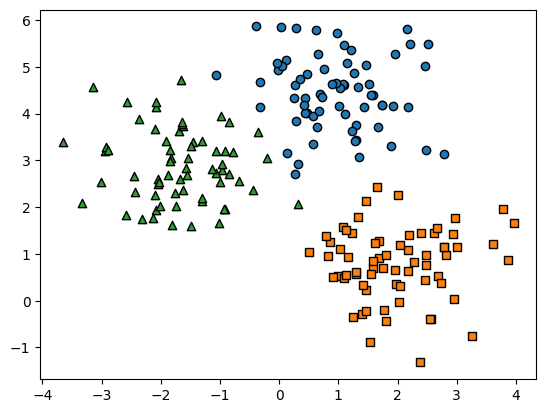

In [12]:
target_list = np.unique(y)
# 각 타깃별 산점도의 마커 값
markers = ['o', 's', '^', 'P', 'D', 'H', 'x']
# 3개의 군집 영역으로 구분한 데이터 세트를 생성했으므로 target_list는 [0, 1, 2]
# target = 0, target = 1, target = 2로 scatter plot을 marker별로 생성.
for target in target_list:
  target_cluster = clusterDF[clusterDF['target'] == target]
  plt.scatter(x = target_cluster['ftr1'], y = target_cluster['ftr2'], edgecolor = 'k',
              marker = markers[target])
plt.show()

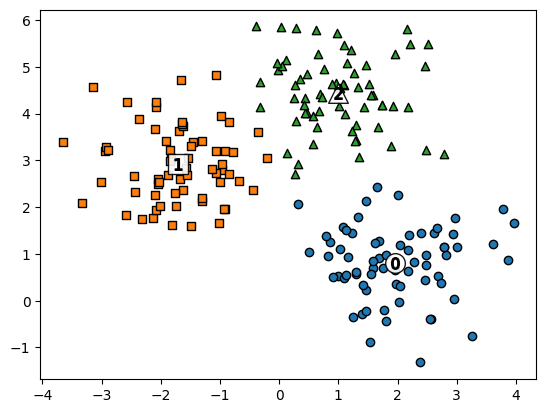

In [15]:
# KMeans 객체를 이용해 X 데이터를 K-Means 클러스터링 수행
kmeans = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 200, random_state = 0)
cluster_labels = kmeans.fit_predict(X)
clusterDF['kmeans_label'] = cluster_labels

# cluster_centers_ 는 개별 클러스터의 중심 위치 좌표 시각화를 위해 추출
centers = kmeans.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers = ['o', 's', '^', 'P', 'D', 'H', 'x']

# 군집된 label 유형별로 iteration 하면서 marker 별로 scatter plot 수행.
for label in unique_labels:
  label_cluster = clusterDF[clusterDF['kmeans_label'] == label]
  center_x_y = centers[label]
  plt.scatter(x = label_cluster['ftr1'], y = label_cluster['ftr2'], edgecolor = 'k',
              marker = markers[label])

  # 군집별 중심 위치 좌표 시각화
  plt.scatter(x = center_x_y[0], y = center_x_y[1], s = 200, color = 'white',
              alpha = 0.9, edgecolor = 'k', marker = markers[label])
  plt.scatter(x = center_x_y[0], y = center_x_y[1], s = 70, color = 'k',
              edgecolor = 'k', marker = '$%d$' % label)
plt.show()

In [16]:
print(clusterDF.groupby('target')['kmeans_label'].value_counts())

target  kmeans_label
0       2               66
        1                1
1       0               67
2       1               65
        0                1
Name: count, dtype: int64


### 7-2. 군집 평가(Cluster Evaluation)

#### 붓꽃 데이터 세트를 이용한 군집 평가

In [17]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
# 실루엣 분석 평가 지표 값을 구하기 위한 API 추가
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
irisDF = pd.DataFrame(data = iris.data, columns = feature_names)
kmeans = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 300, random_state = 0).fit(irisDF)
irisDF['cluster'] = kmeans.labels_

# iris의 모든 개별 데이터에 실루엣 계수 값을 구함.
score_samples = silhouette_samples(iris.data, irisDF['cluster'])
print('silhouette_samples() return 값의 shape', score_samples.shape)

# irisDF에 실루엣 계수 칼럼 추가
irisDF['silhouette_coeff'] = score_samples

# 모든 데이터의 평균 실루엣 계수 값을 구함.
average_score = silhouette_score(iris.data, irisDF['cluster'])
print('붓꽃 데이터 세트 Silhouette Analysis Score:{0:.3f}'.format(average_score))
irisDF.head(3)

silhouette_samples() return 값의 shape (150,)
붓꽃 데이터 세트 Silhouette Analysis Score:0.551


,sepal_length,sepal_width,petal_length,petal_width,cluster,silhouette_coeff
0,5.1,3.5,1.4,0.2,1,0.852582
1,4.9,3.0,1.4,0.2,1,0.814916
2,4.7,3.2,1.3,0.2,1,0.828797


In [19]:
irisDF.groupby('cluster')['silhouette_coeff'].mean()

,silhouette_coeff
cluster,
0,0.422323
1,0.797604
2,0.436842


#### 군집별 평균 실루엣 계수의 시각화를 통한 군집 개수 최적화 방법

In [22]:
# visualize_silhouette([2, 3, 4, 5], X_features)

In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def visualize_silhouette(cluster_list, X):
  from matplotlib import pyplot as plt

  for n_clusters in cluster_list:
    fig, ax1 = plt.subplots(1)
    fig.set_size_inches(6, 4)

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    kmeans = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = kmeans.fit_predict(X)

    silhouette_vals = silhouette_samples(X, cluster_labels)
    silhouette_avg = silhouette_score(X, cluster_labels)

    y_lower = 10

    for i in range(n_clusters):
      ith_silhouette_vals = silhouette_vals[cluster_labels == i]
      ith_silhouette_vals.sort()

      size_cluster_i = ith_silhouette_vals.shape[0]
      y_upper = y_lower + size_cluster_i

      color = cm.nipy_spectral(float(i) / n_clusters)
      ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_silhouette_vals,
                        facecolor=color, edgecolor=color, alpha=0.7)

      ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
      y_lower = y_upper + 10

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_title(f"Silhouette plot for {n_clusters} clusters")
    ax1.set_xlabel("Silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    plt.tight_layout()
    plt.show()

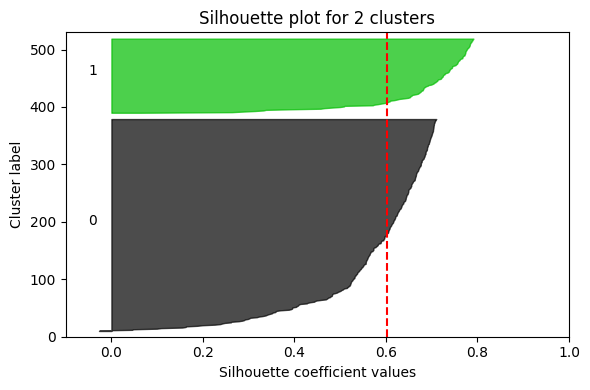

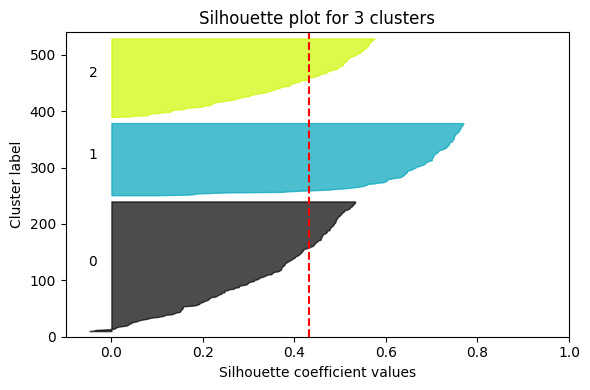

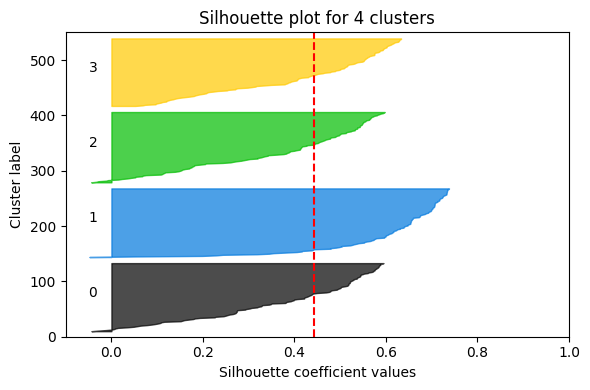

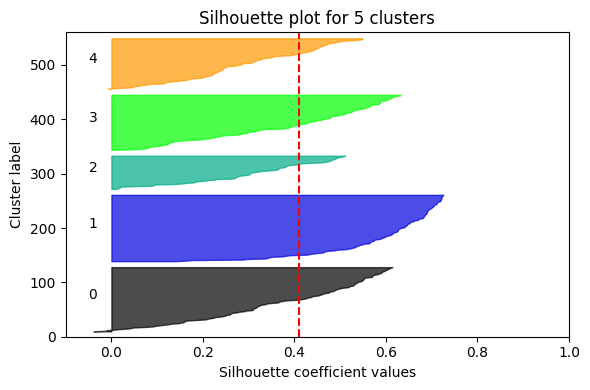

In [28]:
# make_blobs를 통해 군집화를 위한 4개의 군집 중심의 500개 2차원 데이터 세트 생성
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples = 500, n_features = 2, centers = 4, cluster_std = 1,
                  center_box = (-10,0, 10.0), shuffle = True, random_state = 1)

# 군집 개수가 2개, 3개, 4개, 5개일 때의 군집별 실루엣 계수 평균값을 시각화
visualize_silhouette([2, 3, 4, 5], X)

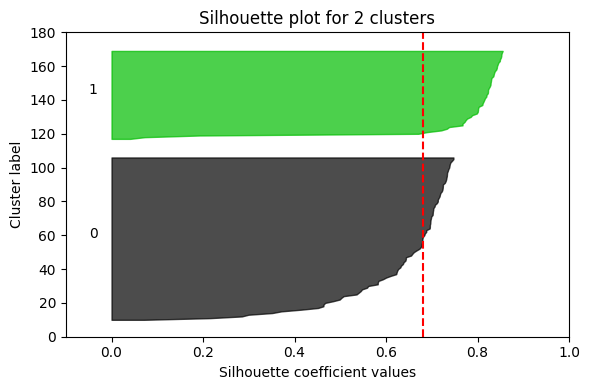

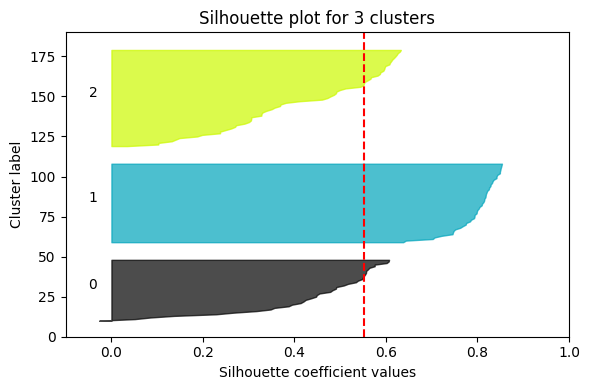

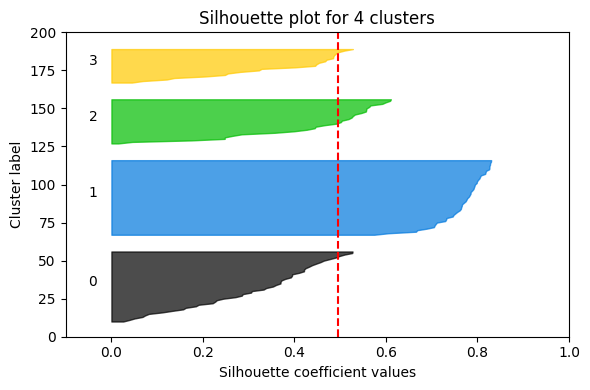

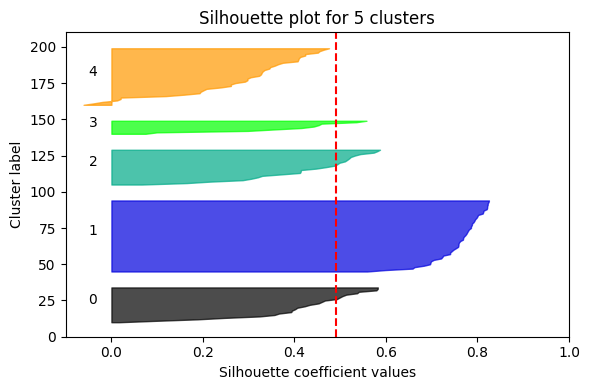

In [29]:
from sklearn.datasets import load_iris
iris = load_iris()
visualize_silhouette([2, 3, 4, 5], iris.data)